<a href="https://colab.research.google.com/github/YUFEIFUT/SparrowRecSys/blob/read_source/TFRecModel/src/com/sparrowrecsys/offline/ipynb/colab%E4%BD%9C%E4%B8%BAtf_serving%E7%9A%84%E6%B5%8B%E8%AF%95%E6%9C%8D%E5%8A%A1%E5%99%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 安装 TensorFlow Serving
此单元格将添加 TensorFlow Serving 的软件包源，并安装模型服务器。

In [1]:
# 添加 TensorFlow Serving 的 APT 软件源
!echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -

# 更新软件列表并安装 tensorflow-model-server
!apt update
!apt-get install tensorflow-model-server

deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100  2943  100  2943    0     0   1903      0  0:00:01  0:00:01 --:--:--  1903
OK
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http

安装完成后，您可以通过运行以下命令来确认安装的版本。

In [2]:
# 检查 TensorFlow Model Server 的版本
!tensorflow_model_server --version

TensorFlow ModelServer: 2.20.0+dev.sha.bc7e9d2
TensorFlow Library: 2.20.0-dev0+selfbuilt


### 下载测试模型数据
我们将克隆 TensorFlow Serving 的仓库以获取官方提供的测试模型（如 `half_plus_two`）。

In [3]:
# 克隆仓库（如果目录已存在则跳过）
import os
if not os.path.exists('serving'):
    !git clone https://github.com/tensorflow/serving

# 设置测试数据路径
import os
testdata_path = os.path.join(os.getcwd(), "serving/tensorflow_serving/servables/tensorflow/testdata")
model_path = os.path.join(testdata_path, "saved_model_half_plus_two_cpu")

print(f"模型路径: {model_path}")

Cloning into 'serving'...
remote: Enumerating objects: 40288, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 40288 (delta 169), reused 86 (delta 83), pack-reused 40055 (from 3)
Receiving objects: 100% (40288/40288), 19.90 MiB | 10.25 MiB/s, done.
Resolving deltas: 100% (32808/32808), done.
模型路径: /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu


### 启动 TensorFlow Serving 服务
由于 Colab 不方便运行 Docker 容器，我们直接使用已安装的 `tensorflow_model_server` 在后台启动服务。

In [4]:
# 使用 nohup 在后台启动模型服务器，监听 8501 端口
os.environ['MODEL_PATH'] = model_path

!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=half_plus_two \
    --model_base_path=$MODEL_PATH > server.log 2>&1 &

print("TensorFlow Serving 正在后台启动... 日志将写入 server.log")

TensorFlow Serving 正在后台启动... 日志将写入 server.log


### 验证服务是否成功启动
等待几秒钟后，我们可以检查日志或尝试发送一个预测请求。

In [5]:
# 检查日志最后几行，看是否加载成功
!tail server.log

# 发送一个测试请求
!curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST http://localhost:8501/v1/models/half_plus_two:predict

2026-06-22 04:21:54.973545: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 34750 microseconds.
2026-06-22 04:21:54.973681: I tensorflow_serving/servables/tensorflow/saved_model_warmup_util.cc:85] No warmup data file found at /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu/00000123/assets.extra/tf_serving_warmup_requests
2026-06-22 04:21:55.106341: I tensorflow_serving/core/loader_harness.cc:104] Successfully loaded servable version {name: half_plus_two version: 123}
I0000 00:00:1782102115.107112    3768 server_core.cc:537] Finished adding/updating models
2026-06-22 04:21:55.108189: I tensorflow_serving/model_servers/server.cc:124] Using InsecureServerCredentials
2026-06-22 04:21:55.108393: I tensorflow_serving/model_servers/server.cc:395] Profiler service is enabled
2026-06-22 04:21:55.109156: I tensorflow_serving/model_servers/server.cc:430] Running gRPC Mo

### 使用 ngrok 暴露公网访问接口
我们将安装 `pyngrok` 并通过它将本地的 8501 端口映射到公网。

In [6]:
# 安装 pyngrok
!pip install pyngrok

请在下方填入您的 ngrok Authtoken（可以从 ngrok 官网控制台获取）。

In [7]:
from pyngrok import ngrok
from google.colab import userdata
import os

try:
    # 从 Colab Secrets 中安全读取 Token
    # 请确保您已在左侧“钥匙”面板添加了名为 NGROK_TOKEN 的变量
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')

    # 尝试关闭现有的 ngrok 进程以防冲突
    ngrok.kill()
    # 设置 Token
    ngrok.set_auth_token(NGROK_TOKEN)

    # 创建 HTTP 隧道指向 TensorFlow Serving 的 8501 端口
    tunnel = ngrok.connect(8501, "http")
    public_url = tunnel.public_url
    print(f"TensorFlow Serving 公网访问地址: {public_url}")
except userdata.SecretNotFoundError:
    print("❌ 错误：未在 Colab Secrets 中找到 NGROK_TOKEN。")
    print("请点击左侧钥匙图标，添加 Name 为 NGROK_TOKEN 的密钥并开启访问权限。")
except Exception as e:
    print(f"发生错误: {e}")

TensorFlow Serving 公网访问地址: https://footbath-naming-impaired.ngrok-free.dev


### 外部访问示例
现在您可以复制上面的 `public_url` 地址，在您的本地终端或其他代码中使用它。示例：

In [8]:
# 确保 public_url 已成功定义后再进行打印
if 'public_url' in locals():
    print(f"您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:")
    print(f"curl -d '{{\"instances\": [1.0, 2.0, 5.0]}}' -X POST {public_url}/v1/models/half_plus_two:predict")
else:
    print("❌ 公网隧道尚未成功建立。请先在上面的单元格中填入正确的 Token 并运行成功。")

您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:
curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict


windows上调用

curl -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict -H "Content-Type: application/json" -d "{\"instances\": [1.0, 2.0, 5.0]}"

## 克隆仓库

In [9]:
!git clone https://github.com/wzhe06/SparrowRecSys

Cloning into 'SparrowRecSys'...
remote: Enumerating objects: 2124, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 2124 (delta 72), reused 66 (delta 66), pack-reused 1986 (from 1)
Receiving objects: 100% (2124/2124), 65.03 MiB | 16.04 MiB/s, done.
Resolving deltas: 100% (363/363), done.


### EmbeddingMLP.py

### 现代 Keras 实现版本 (适配 Keras 3 / TF 2.16+)
由于 `tf.feature_column` 及其相关的 `DenseFeatures` 在新版本中已不再推荐使用且存在严重的 API 路径变更问题，本单元格使用 Keras 原生的 **Preprocessing Layers** (如 `StringLookup`, `IntegerLookup`) 重新实现。这种方式将特征处理直接嵌入到模型中，无需外部特征层。

<font color='red'>这个就当作注释看吧，也不用运行了</font>

In [27]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# 1. 指定训练集和测试集的路径
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamples.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamples.csv"

# 2. 定义特征清单与词表
# 电影风格（Genre）的全量枚举值，用于构建 StringLookup 的词表
genre_vocab = ['Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance', 'War', 'Comedy', 'Western', 'Documentary',
               'Sci-Fi', 'Drama', 'Thriller', 'Crime', 'Fantasy', 'Animation', 'IMAX', 'Mystery', 'Children', 'Musical']

# 类别特征列表（包含用户偏好风格和电影自身风格）
genre_features = ['userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
                  'movieGenre1', 'movieGenre2', 'movieGenre3']
# 数值型特征列表（发行年份、评分统计信息等）
numeric_features = ['releaseYear', 'movieRatingCount', 'movieAvgRating',
                    'movieRatingStddev', 'userRatingCount', 'userAvgRating', 'userRatingStddev']

# 3. 构造输入层并进行预处理
all_inputs = {}  # 保存所有输入层
encoded_features = []  # 保存经过处理后的特征

# --- A. 处理数值特征 ---
for header in numeric_features:
    # 为每个数值特征定义一个 Input 层，接收 float32 类型数据
    # 为什么 shape=(1,)？因为一个特征只有一个数字
    numeric_col = tf.keras.Input(shape=(1,), name=header, dtype='float32')
    all_inputs[header] = numeric_col
    # 数值特征直接加入特征列表，无需额外转换
    encoded_features.append(numeric_col)

# --- B. 处理 Genre 类别特征 (String -> Embedding) ---
for header in genre_features:
    # 定义接收字符串的输入层
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
    all_inputs[header] = categorical_col
    # 使用 StringLookup 将字符串映射为整数索引：
    # - vocabulary: 使用预定义的风格词表
    # - num_oov_indices: 设为 1，用于处理词表外的未知风格
    lookup_layer = layers.StringLookup(vocabulary=genre_vocab, mask_token=None, num_oov_indices=1)
    index = lookup_layer(categorical_col)
    # 使用 Embedding 层将索引转换为 10 维稠密向量
    # input_dim 为词表大小 + OOV + 1【这里原本的代码底层逻辑是咋样的？】
    embedding = layers.Embedding(input_dim=len(genre_vocab) + 2, output_dim=10)(index)
    # 将 Embedding 输出展平（从 [batch, 1, 10] 变为 [batch, 10]）以便拼接
    encoded_features.append(layers.Flatten()(embedding))

# --- C. 处理 ID 特征 (Int -> Embedding) ---
# 电影 ID：假设范围 1001 以内
movie_id_input = tf.keras.Input(shape=(1,), name='movieId', dtype='int64')
all_inputs['movieId'] = movie_id_input
movie_embedding = layers.Embedding(input_dim=1001, output_dim=10)(movie_id_input)
encoded_features.append(layers.Flatten()(movie_embedding))

# 用户 ID：假设范围 30001 以内
user_id_input = tf.keras.Input(shape=(1,), name='userId', dtype='int64')
all_inputs['userId'] = user_id_input
user_embedding = layers.Embedding(input_dim=30001, output_dim=10)(user_id_input)
encoded_features.append(layers.Flatten()(user_embedding))

# 4. 构建 MLP 网络 (多层感知机)
# 将所有处理后的特征（数值 + Embedding）拼接成一个长向量
#【之前的代码应该是多种特征加起来吧，现在的layers.Concatenate()(encoded_features)是什么逻辑？】
all_features = layers.Concatenate()(encoded_features)
# 两个隐藏层，每层 128 个神经元，使用 ReLU 激活函数增强非线性表达能力
x = layers.Dense(128, activation="relu")(all_features)
x = layers.Dense(128, activation="relu")(x)
# 输出层使用 Sigmoid 激活函数，输出 0 到 1 之间的点击概率值
output = layers.Dense(1, activation="sigmoid")(x)

# 定义 Keras 函数式模型
new_model = tf.keras.Model(all_inputs, output)

# 5. 编译模型
new_model.compile(
    optimizer='adam',                # Adam 优化器，自动调节学习率
    loss='binary_crossentropy',      # 二分类交叉熵损失函数
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc', curve='ROC')])

# 6. 优化的数据加载函数
def df_to_dataset(file_path, batch_size=32):
    """将 CSV 文件加载并转换为 tf.data.Dataset 格式"""
    df = pd.read_csv(file_path)
    feature_cols = numeric_features + genre_features + ['movieId', 'userId']

    # 标签转换为 float32
    labels = df['label'].values.astype('float32')

    # 数据清洗与类型转换
    # 1. 数值特征：填充缺失值为 0，强制转为 float32
    df[numeric_features] = df[numeric_features].fillna(0).astype('float32')
    # 2. 类别特征：填充缺失值为 'None'，强制转为 string 防止 Pandas 误识别类型
    df[genre_features] = df[genre_features].fillna('None').astype(str)
    # 3. ID 特征：取模运算确保数值不会超出 Embedding 层的 input_dim 范围
    df['movieId'] = df['movieId'].fillna(0).astype('int64') % 1001
    df['userId'] = df['userId'].fillna(0).astype('int64') % 30001

    # 构建输入字典
    input_dict = {col: df[col].values for col in feature_cols}
    # 转换为 TF 数据集
    ds = tf.data.Dataset.from_tensor_slices((input_dict, labels))
    return ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# 准备训练和测试数据
train_ds = df_to_dataset(train_path)
test_ds = df_to_dataset(test_path)

# 7. 设置早停法回调 (EarlyStopping)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',    # 监控验证集的 AUC
    patience=5,               # 如果连续 3 个 epoch 指标没提升就停止
    mode='max',               # 目标是最大化 AUC
    restore_best_weights=True # 停止后恢复最优权重
)

# 8. 执行训练 (赋值给 history 变量以供绘图)
print("开始带有早停法的模型训练...")
history = new_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,                # 设置较大的上限
    callbacks=[early_stopping]
)

# 9. 最终评估
loss, accuracy, auc = new_model.evaluate(test_ds)
print(f"\n最终评估结果: Loss: {loss:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

开始带有早停法的模型训练...
Epoch 1/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.5693 - loss: 4.5311 - roc_auc: 0.5785 - val_accuracy: 0.5273 - val_loss: 6.4218 - val_roc_auc: 0.5942
Epoch 2/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.6013 - loss: 1.8835 - roc_auc: 0.6200 - val_accuracy: 0.4489 - val_loss: 2.1983 - val_roc_auc: 0.5602
Epoch 3/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.6761 - loss: 0.7674 - roc_auc: 0.7185 - val_accuracy: 0.6711 - val_loss: 0.6264 - val_roc_auc: 0.7477
Epoch 4/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - accuracy: 0.7403 - loss: 0.5363 - roc_auc: 0.8096 - val_accuracy: 0.6712 - val_loss: 0.6600 - val_roc_auc: 0.7512
Epoch 5/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.7699 - loss: 0.4789 - roc_auc: 0.8476 - val_accuracy: 0.6716 - val_loss: 0.6637 - val_roc_auc: 0.7357
Epoch 6/50
2776/2776 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.7819 - loss: 0.4554 - roc_auc: 0.8627 - val_accuracy: 

### ChatGPT修正的

In [40]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# 1. 指定训练集和测试集的路径
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamples.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamples.csv"

# 2. 定义特征清单与词表
genre_vocab = [
    'Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance',
    'War', 'Comedy', 'Western', 'Documentary', 'Sci-Fi',
    'Drama', 'Thriller', 'Crime', 'Fantasy', 'Animation',
    'IMAX', 'Mystery', 'Children', 'Musical'
]

genre_features = [
    'userGenre1', 'userGenre2', 'userGenre3',
    'userGenre4', 'userGenre5',
    'movieGenre1', 'movieGenre2', 'movieGenre3'
]

numeric_features = [
    'releaseYear',
    'movieRatingCount',
    'movieAvgRating',
    'movieRatingStddev',
    'userRatingCount',
    'userAvgRating',
    'userRatingStddev'
]

# =====================================
# 3. 构造输入层
# =====================================

all_inputs = {}
encoded_features = []

# --- 数值特征 ---
for header in numeric_features:
    numeric_col = tf.keras.Input(
        shape=(1,),
        name=header,
        dtype='float32'
    )

    all_inputs[header] = numeric_col
    encoded_features.append(numeric_col)

# --- Genre特征 ---
for header in genre_features:

    categorical_col = tf.keras.Input(
        shape=(1,),
        name=header,
        dtype='string'
    )

    all_inputs[header] = categorical_col

    lookup_layer = layers.StringLookup(
        vocabulary=genre_vocab,
        mask_token=None,
        num_oov_indices=1
    )

    index = lookup_layer(categorical_col)

    embedding = layers.Embedding(
        input_dim=len(genre_vocab) + 2,
        output_dim=10
    )(index)

    encoded_features.append(
        layers.Flatten()(embedding)
    )

# --- Movie ID ---
movie_id_input = tf.keras.Input(
    shape=(1,),
    name='movieId',
    dtype='int64'
)

all_inputs['movieId'] = movie_id_input

movie_embedding = layers.Embedding(
    input_dim=1001,
    output_dim=10
)(movie_id_input)

encoded_features.append(
    layers.Flatten()(movie_embedding)
)

# --- User ID ---
user_id_input = tf.keras.Input(
    shape=(1,),
    name='userId',
    dtype='int64'
)

all_inputs['userId'] = user_id_input

user_embedding = layers.Embedding(
    input_dim=30001,
    output_dim=10
)(user_id_input)

encoded_features.append(
    layers.Flatten()(user_embedding)
)

# =====================================
# 4. MLP
# =====================================

all_features = layers.Concatenate()(encoded_features)

x = layers.Dense(
    128,
    activation="relu"
)(all_features)

x = layers.Dense(
    128,
    activation="relu"
)(x)

output = layers.Dense(
    1,
    activation="sigmoid"
)(x)

new_model = tf.keras.Model(
    all_inputs,
    output
)

# =====================================
# 5. 编译模型
# =====================================

new_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(
            name='roc_auc',
            curve='ROC'
        )
    ]
)

# =====================================
# 6. DataFrame -> Dataset
# =====================================

def df_to_dataset(df, batch_size=32):

    df = df.copy()

    feature_cols = (
        numeric_features
        + genre_features
        + ['movieId', 'userId']
    )

    labels = df['label'].values.astype('float32')

    # 数值特征
    df[numeric_features] = (
        df[numeric_features]
        .fillna(0)
        .astype('float32')
    )

    # Genre特征
    df[genre_features] = (
        df[genre_features]
        .fillna('None')
        .astype(str)
    )

    # ID特征
    df['movieId'] = (
        df['movieId']
        .fillna(0)
        .astype('int64')
        % 1001
    )

    df['userId'] = (
        df['userId']
        .fillna(0)
        .astype('int64')
        % 30001
    )

    input_dict = {
        col: df[col].values
        for col in feature_cols
    }

    ds = tf.data.Dataset.from_tensor_slices(
        (input_dict, labels)
    )

    return (
        ds
        .shuffle(len(df))
        .batch(batch_size)
        .cache()
        .prefetch(tf.data.AUTOTUNE)
    )

# =====================================
# 7. 数据划分
# =====================================

print("加载训练数据...")

full_train_df = pd.read_csv(train_path)

# 随机打乱
full_train_df = full_train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

split_index = int(
    len(full_train_df) * 0.8
)

train_df = full_train_df.iloc[:split_index]

val_df = full_train_df.iloc[split_index:]

print(f"训练集大小: {len(train_df)}")
print(f"验证集大小: {len(val_df)}")

# 真正测试集
test_df = pd.read_csv(test_path)

print(f"测试集大小: {len(test_df)}")

# 转 Dataset
train_ds = df_to_dataset(train_df)

val_ds = df_to_dataset(val_df)

test_ds = df_to_dataset(test_df)

# =====================================
# 8. EarlyStopping
# =====================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',
    patience=5,
    mode='max',
    restore_best_weights=True
)

# =====================================
# 9. 模型训练
# =====================================

print("开始训练模型...")

history = new_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping]
)

# =====================================
# 10. 最终测试
# =====================================

print("\n开始最终测试评估...")

loss, accuracy, auc = new_model.evaluate(
    test_ds
)

print(
    f"\n最终评估结果:"
    f"\nLoss: {loss:.4f}"
    f"\nAccuracy: {accuracy:.4f}"
    f"\nAUC: {auc:.4f}"
)

加载训练数据...
训练集大小: 71061
验证集大小: 17766
测试集大小: 22440
开始训练模型...
Epoch 1/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.5693 - loss: 5.8163 - roc_auc: 0.5775 - val_accuracy: 0.4485 - val_loss: 6.8112 - val_roc_auc: 0.5170
Epoch 2/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.6352 - loss: 1.9987 - roc_auc: 0.6630 - val_accuracy: 0.6841 - val_loss: 0.7912 - val_roc_auc: 0.7438
Epoch 3/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.6834 - loss: 1.2275 - roc_auc: 0.7280 - val_accuracy: 0.6769 - val_loss: 0.7736 - val_roc_auc: 0.7318
Epoch 4/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7165 - loss: 0.8017 - roc_auc: 0.7741 - val_accuracy: 0.6826 - val_loss: 0.7709 - val_roc_auc: 0.7368
Epoch 5/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7430 - loss: 0.5866 - roc_auc: 0.8144 - val_accuracy: 0.6716 - val_loss: 0.8025 - val_roc_auc: 0.7420
Epoch 6/50
2221/2221 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.7575 - loss

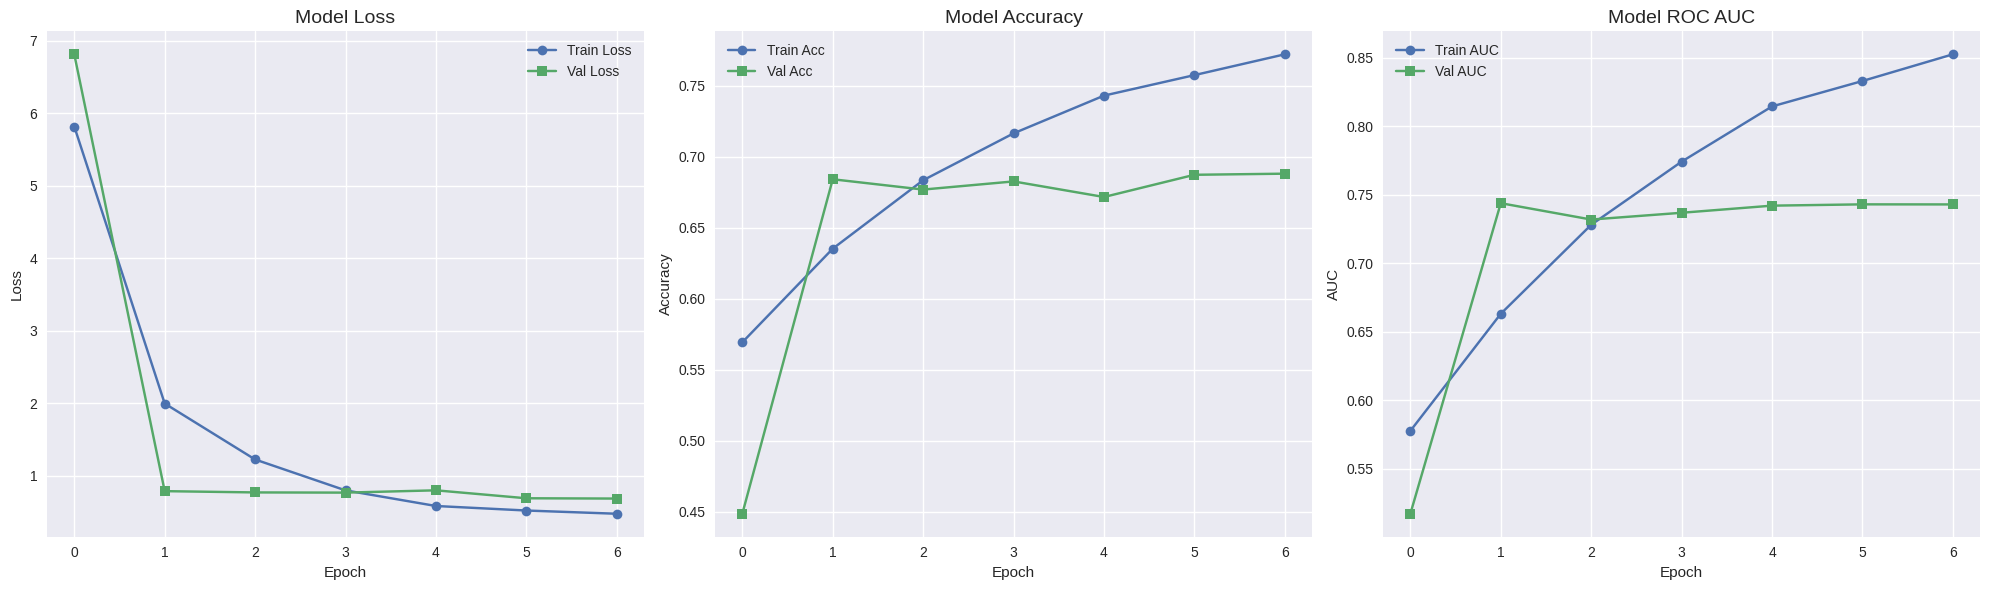

In [41]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s')
axes[1].set_title('Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线
axes[2].plot(history.history['roc_auc'], label='Train AUC', marker='o')
axes[2].plot(history.history['val_roc_auc'], label='Val AUC', marker='s')
axes[2].set_title('Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出模型为 SavedModel 格式
TensorFlow Serving 需要 SavedModel 格式。我们将模型保存到 `/content/models/embedding_mlp/1`（'1' 是版本号）。

In [42]:
import os

# 定义模型保存路径，包含版本号
export_path = "/content/models/embedding_mlp/1"

# 如果目录已存在则先删除，确保干净导出
if os.path.exists(export_path):
    import shutil
    shutil.rmtree(export_path)

# 在 Keras 3 中，导出为 SavedModel (供 TF Serving 使用) 需使用 export 方法
# 这种方式会自动处理 SavedModel 的签名，不再依赖 .save() 的后缀识别
new_model.export(export_path)

print(f"模型已成功导出至: {export_path}")
# 查看导出目录结构，确认包含 fingerprint.pb 和 variables
!ls -l {export_path}

Saved artifact at '/content/models/embedding_mlp/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userGenre1', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre1')], ['userGenre2', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre2')], ['userGenre3', TensorSpec(shape=(None, 1), dtype=tf.str

### 2. 部署到 TensorFlow Serving
我们需要杀掉之前运行的 `half_plus_two` 服务的进程，并启动新的服务来加载我们的 `embedding_mlp` 模型。

In [43]:
# 1. 停止之前的服务进程
!pkill -f tensorflow_model_server

# 2. 设置新的模型基础路径（注意不带版本号）
os.environ['NEW_MODEL_BASE_PATH'] = "/content/models/embedding_mlp"

# 3. 启动后台服务
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_mlp \
    --model_base_path=$NEW_MODEL_BASE_PATH > server_new.log 2>&1 &

print("新的模型服务器正在启动... 日志输出至 server_new.log")

新的模型服务器正在启动... 日志输出至 server_new.log


### 3. 验证新模型接口
等待几秒钟确保模型加载完成后，我们尝试调用 API 接口。

In [44]:
import time
print("正在重启服务以加载新导出的模型...")
# 停止旧进程
!pkill -f tensorflow_model_server

# 重新启动服务
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_mlp \
    --model_base_path=/content/models/embedding_mlp > server_new.log 2>&1 &

time.sleep(5) # 等待服务器就绪

# 检查日志确保加载成功
print("--- 最近的服务器日志 ---")
!tail -n 5 server_new.log

# 打印公网访问地址
if 'public_url' in locals():
    print(f"\n新模型的公网访问接口: {public_url}/v1/models/sparrow_mlp:predict")

正在重启服务以加载新导出的模型...
--- 最近的服务器日志 ---
I0000 00:00:1782108985.094647   39853 server_core.cc:645]  (Re-)adding model: sparrow_mlp
I0000 00:00:1782108985.654855   39867 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782108986.042791   39853 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...

新模型的公网访问接口: https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict


### 4. 真实数据预测测试
我们将从测试集中提取一条数据，构造符合模型输入格式的 JSON，并通过 REST API 发送给 TensorFlow Serving。

In [37]:
import requests
import json
import pandas as pd

# 1. 加载一小部分测试数据
test_df = pd.read_csv("/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamples.csv").head(1)

# 2. 准备输入数据 (需严格匹配导出模型时的输入层名称和类型)
# 注意：数值填 0，类别填 'None'，ID 取模，这与训练时的预处理一致
instance = {}
for col in numeric_features:
    instance[col] = [float(test_df[col].fillna(0).iloc[0])]
for col in genre_features:
    instance[col] = [str(test_df[col].fillna('None').iloc[0])]
instance['movieId'] = [int(test_df['movieId'].fillna(0).iloc[0]) % 1001]
instance['userId'] = [int(test_df['userId'].fillna(0).iloc[0]) % 30001]

# 3. 构造请求体
data = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

# 4. 发送预测请求
predict_url = f"{public_url}/v1/models/sparrow_mlp:predict"
print(f"正在请求接口: {predict_url}")

response = requests.post(predict_url, data=data, headers=headers)

if response.status_code == 200:
    result = response.json()
    prediction = result['predictions'][0][0]
    print(f"\n预测成功！")
    print(f"输入样本的预测点击概率 (CTR): {prediction:.4f}")
    print(f"实际标签 (Label): {test_df['label'].iloc[0]}")
else:
    print(f"\n预测失败！")
    print(f"状态码: {response.status_code}")
    print(f"错误信息: {response.text}")

正在请求接口: https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict

预测成功！
输入样本的预测点击概率 (CTR): 0.8439
实际标签 (Label): 0


### Windows CMD `curl` 调用命令示例
将以下命令复制并粘贴到您的 Windows `cmd.exe` 命令行中执行：


In [39]:
import json

# 提取模型所需的特征值
# 数据来源: 204,2162,4.0,836418450,1,1995,Action,"","",1782,2.97,1.06,261,377,440,11,589,39,1993,1.47,3.82,1.00,Drama,Adventure,Action,Thriller,Romance

instance_data = {
    'movieId': [204],
    'userId': [2162],
    'releaseYear': [1995.0],
    'movieRatingCount': [1782.0],
    'movieAvgRating': [2.97],
    'movieRatingStddev': [1.06],
    'userRatingCount': [39.0],
    'userAvgRating': [3.82],
    'userRatingStddev': [1.00],
    'userGenre1': ['Drama'],
    'userGenre2': ['Adventure'],
    'userGenre3': ['Action'],
    'userGenre4': ['Thriller'],
    'userGenre5': ['Romance'],
    'movieGenre1': ['Action'],
    'movieGenre2': ['None'], # Original data was empty, mapped to 'None'
    'movieGenre3': ['None']  # Original data was empty, mapped to 'None'
}

# 构造 JSON payload，使用 separators=(',', ':') 避免不必要的空白，方便 CMD 处理
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 为 Windows CMD 逃逸内部双引号
escaped_json_payload = json_payload.replace('"', '\"')

# 构建 curl 命令
# public_url 变量来自之前的 ngrok 隧道单元格
curl_command_windows = f'curl -X POST "{public_url}/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{escaped_json_payload}"'

print("```bash") # 使用 markdown 代码块方便复制
print(curl_command_windows)
print("```")

```bash
curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{"instances":[{"movieId":[204],"userId":[2162],"releaseYear":[1995.0],"movieRatingCount":[1782.0],"movieAvgRating":[2.97],"movieRatingStddev":[1.06],"userRatingCount":[39.0],"userAvgRating":[3.82],"userRatingStddev":[1.0],"userGenre1":["Drama"],"userGenre2":["Adventure"],"userGenre3":["Action"],"userGenre4":["Thriller"],"userGenre5":["Romance"],"movieGenre1":["Action"],"movieGenre2":["None"],"movieGenre3":["None"]}]}"
```


### 4. 真实数据预测测试
我们将从测试集中提取一条数据，构造符合模型输入格式的 JSON，并通过 REST API 发送给 TensorFlow Serving。

In [36]:
import requests
import json
import pandas as pd

# 1. 加载一小部分测试数据
test_df = pd.read_csv("/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamples.csv").head(1)

# 2. 准备输入数据 (需严格匹配导出模型时的输入层名称和类型)
# 注意：数值填 0，类别填 'None'，ID 取模，这与训练时的预处理一致
instance = {}
for col in numeric_features:
    instance[col] = [float(test_df[col].fillna(0).iloc[0])]
for col in genre_features:
    instance[col] = [str(test_df[col].fillna('None').iloc[0])]
instance['movieId'] = [int(test_df['movieId'].fillna(0).iloc[0]) % 1001]
instance['userId'] = [int(test_df['userId'].fillna(0).iloc[0]) % 30001]

# 3. 构造请求体
data = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

# 4. 发送预测请求
predict_url = f"{public_url}/v1/models/sparrow_mlp:predict"
print(f"正在请求接口: {predict_url}")

response = requests.post(predict_url, data=data, headers=headers)

if response.status_code == 200:
    result = response.json()
    prediction = result['predictions'][0][0]
    print(f"\n预测成功！")
    print(f"输入样本的预测点击概率 (CTR): {prediction:.4f}")
    print(f"实际标签 (Label): {test_df['label'].iloc[0]}")
else:
    print(f"\n预测失败！")
    print(f"状态码: {response.status_code}")
    print(f"错误信息: {response.text}")

正在请求接口: https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict

预测成功！
输入样本的预测点击概率 (CTR): 0.8439
实际标签 (Label): 0
